# **Imports and load raw data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import joblib
import json
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:,.4f}".format)

df = pd.read_csv("../../ml/data/synthetic/properties_raw.csv")
print(f"Raw dataset shape: {df.shape}")
print(f"\nFirst record:\n{df.iloc[0]}")

Raw dataset shape: (50000, 23)

First record:
id                               0
city                       Mombasa
neighbourhood               Likoni
country                      Kenya
currency                       KES
property_type            apartment
bedrooms                         3
bathrooms                        2
floor_area_sqm             57.4000
furnishing               furnished
price                  20,100.0000
price_period                yearly
latitude                   -4.0915
longitude                  39.6944
distance_to_cbd_km          6.0800
infrastructure_score        5.9400
transit_access_score        6.5000
amenity_count                    3
listing_month                   17
account_age_days               133
listing_count                    1
tier                             3
is_fraud                         0
Name: 0, dtype: object


> Loads the 50,000 record dataset.
> We check the first record to confirm all columns loaded correctly before touching anything.

# **Separate clean from fraud, work on clean only for training**

In [2]:
clean_df = df[df.is_fraud == 0].copy().reset_index(drop=True)
fraud_df = df[df.is_fraud == 1].copy().reset_index(drop=True)

print(f"Clean records:  {len(clean_df):,}")
print(f"Fraud records:  {len(fraud_df):,}")
print(f"\nProperty type distribution (clean):")
print(clean_df.property_type.value_counts())
print(f"\nPrice period distribution (clean):")
print(clean_df.price_period.value_counts())

Clean records:  47,500
Fraud records:  2,500

Property type distribution (clean):
property_type
apartment     18074
house         13195
bedsitter      7685
land           4722
commercial     3824
Name: count, dtype: int64

Price period distribution (clean):
price_period
monthly    27867
once       13365
yearly      6268
Name: count, dtype: int64


>We separate fraud from clean records immediately. The valuation and trend models train only on clean data — we don't want the model learning that fraud-priced properties are normal. Fraud records are kept separately for the fraud model training in notebook 04.

# **Remove land from valuation dataset**

In [3]:
# Land has no bedrooms, bathrooms, floor area — different product entirely
# It will skew the valuation model — train separately later if needed
valuation_df = clean_df[clean_df.property_type != "land"].copy().reset_index(drop=True)
print(f"Records after removing land: {len(valuation_df):,}")
print(f"\nProperty types remaining:")
print(valuation_df.property_type.value_counts())

Records after removing land: 42,778

Property types remaining:
property_type
apartment     18074
house         13195
bedsitter      7685
commercial     3824
Name: count, dtype: int64


>Land properties have 0 bedrooms, 0 bathrooms, and 0 floor area — structurally different from residential and commercial properties. Including them would confuse the valuation model since all their size features are zero. We exclude them from valuation training.

# **Create price normalisation within city**

Log price stats:
count   42,778.0000
mean        12.8810
std          3.0270
min          6.9090
25%         10.6760
50%         12.4950
75%         14.7560
max         22.4980
Name: log_price, dtype: float64

Z-score stats (should be ~0 mean, ~1 std):
count   42,778.0000
mean        -0.0000
std          1.0000
min         -2.8040
25%         -0.6780
50%          0.1020
75%          0.7210
max          2.7530
Name: price_zscore, dtype: float64


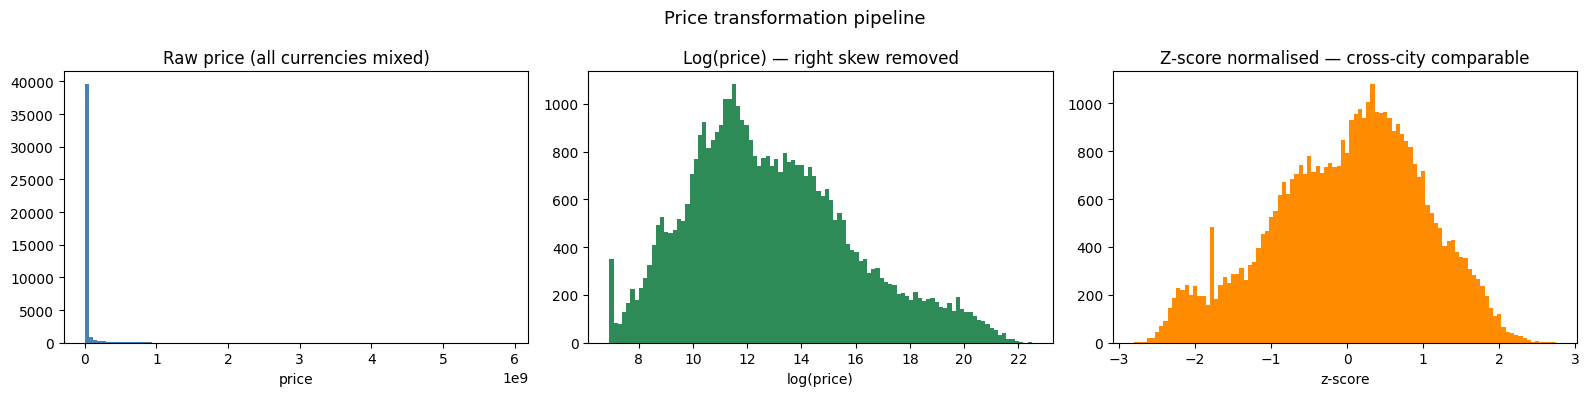

Saved: 02_price_transformation.png


In [4]:
# The core problem: KES 45,000 and TZS 800,000 are similar apartments
# but raw numbers differ by 18x — we must normalise within city+currency groups

# Step 1: Log-transform price (handles right skew within each currency)
valuation_df["log_price"] = np.log1p(valuation_df["price"])

# Step 2: Z-score normalise log_price within each city+price_period group
# This makes "expensive for Nairobi monthly" comparable to "expensive for Lagos monthly"
valuation_df["price_zscore"] = valuation_df.groupby(
    ["city", "price_period"]
)["log_price"].transform(lambda x: (x - x.mean()) / x.std())

print("Log price stats:")
print(valuation_df["log_price"].describe().round(3))
print("\nZ-score stats (should be ~0 mean, ~1 std):")
print(valuation_df["price_zscore"].describe().round(3))

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(valuation_df["price"], bins=100, color="steelblue")
axes[0].set_title("Raw price (all currencies mixed)")
axes[0].set_xlabel("price")

axes[1].hist(valuation_df["log_price"], bins=100, color="seagreen")
axes[1].set_title("Log(price) — right skew removed")
axes[1].set_xlabel("log(price)")

axes[2].hist(valuation_df["price_zscore"], bins=100, color="darkorange")
axes[2].set_title("Z-score normalised — cross-city comparable")
axes[2].set_xlabel("z-score")

plt.suptitle("Price transformation pipeline", fontsize=13)
plt.tight_layout()
plt.savefig("../../ml/reports/02_price_transformation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 02_price_transformation.png")

>This is the most important transformation in the entire pipeline. Raw prices across 6 currencies are incomparable. Log-transform removes the right skew (a few extremely expensive properties pulling the distribution). Z-score normalisation within city+period groups makes the model learn "relatively expensive for this city" rather than absolute currency values.

# **Engineer new features**

In [5]:
# Feature 1: price per square metre (only for properties with floor area)
valuation_df["price_per_sqm"] = np.where(
    valuation_df["floor_area_sqm"] > 0,
    valuation_df["price"] / valuation_df["floor_area_sqm"],
    0
)
valuation_df["log_price_per_sqm"] = np.log1p(valuation_df["price_per_sqm"])

# Feature 2: bedroom to bathroom ratio
valuation_df["bed_bath_ratio"] = np.where(
    valuation_df["bathrooms"] > 0,
    valuation_df["bedrooms"] / valuation_df["bathrooms"],
    valuation_df["bedrooms"]
)

# Feature 3: size category
valuation_df["size_category"] = pd.cut(
    valuation_df["floor_area_sqm"],
    bins=[0, 40, 70, 100, 150, 10000],
    labels=["micro", "small", "medium", "large", "luxury"]
)

# Feature 4: CBD proximity bucket
valuation_df["cbd_proximity"] = pd.cut(
    valuation_df["distance_to_cbd_km"],
    bins=[0, 2, 5, 10, 20, 1000],
    labels=["central", "near", "mid", "outer", "remote"]
)

# Feature 5: infrastructure + amenity composite score
valuation_df["desirability_score"] = (
    valuation_df["infrastructure_score"] * 0.5 +
    valuation_df["transit_access_score"] * 0.3 +
    valuation_df["amenity_count"] * 0.2
)

# Feature 6: listing season (East African rental market peaks)
valuation_df["season"] = valuation_df["listing_month"].apply(
    lambda m: "peak" if (m % 12) in [1, 2, 9, 10] else "normal"
)

# Feature 7: is_furnished binary
valuation_df["is_furnished"] = (
    valuation_df["furnishing"] == "furnished"
).astype(int)

# Feature 8: total rooms
valuation_df["total_rooms"] = valuation_df["bedrooms"] + valuation_df["bathrooms"]

print("New features created:")
new_features = [
    "price_per_sqm", "log_price_per_sqm", "bed_bath_ratio",
    "size_category", "cbd_proximity", "desirability_score",
    "season", "is_furnished", "total_rooms"
]
print(valuation_df[new_features].describe(include="all").round(3).T)

New features created:
                         count unique     top   freq         mean  \
price_per_sqm      42,778.0000    NaN     NaN    NaN 450,887.0400   
log_price_per_sqm  42,778.0000    NaN     NaN    NaN       8.6850   
bed_bath_ratio     42,778.0000    NaN     NaN    NaN       1.2330   
size_category            42778      5   micro  12603          NaN   
cbd_proximity            42778      5     mid  17043          NaN   
desirability_score 42,778.0000    NaN     NaN    NaN       6.3460   
season                   42778      2  normal  28575          NaN   
is_furnished       42,778.0000    NaN     NaN    NaN       0.2230   
total_rooms        42,778.0000    NaN     NaN    NaN       4.0550   

                              std     min      25%        50%         75%  \
price_per_sqm      2,294,689.0510 13.4410 663.2790 3,833.2150 35,588.0810   
log_price_per_sqm          2.9480  2.6700   6.4990     8.2520     10.4800   
bed_bath_ratio             1.0880  0.0000   0.4000     1

>e engineer 9 new features from existing ones. `desirability_score` combines infrastructure, transit, and amenity count into a single signal. `price_per_sqm` normalises price by size. `season` captures East African rental market peaks in January-February (new year relocations) and September-October (school year start). These composite features give the model richer signals than raw columns alone.

# **Encode categorical variables**

In [6]:
# Columns to encode
cat_cols_ohe = ["property_type", "furnishing", "price_period", "season"]
cat_cols_label = ["city", "neighbourhood", "size_category", "cbd_proximity"]

# One-hot encode low-cardinality categoricals
valuation_encoded = pd.get_dummies(
    valuation_df,
    columns=cat_cols_ohe,
    drop_first=False,
    dtype=int
)
print(f"Shape after OHE: {valuation_encoded.shape}")

# Label encode high-cardinality categoricals
label_encoders = {}
for col in cat_cols_label:
    le = LabelEncoder()
    valuation_encoded[f"{col}_enc"] = le.fit_transform(
        valuation_encoded[col].astype(str)
    )
    label_encoders[col] = le
    print(f"  {col}: {len(le.classes_)} unique values encoded")

print(f"\nLabel encoders saved for {list(label_encoders.keys())}")

Shape after OHE: (42778, 42)
  city: 6 unique values encoded
  neighbourhood: 42 unique values encoded
  size_category: 5 unique values encoded
  cbd_proximity: 5 unique values encoded

Label encoders saved for ['city', 'neighbourhood', 'size_category', 'cbd_proximity']


>One-hot encoding for low-cardinality columns (property_type has 4 values, furnishing has 3) — creates a binary column per category. Label encoding for high-cardinality columns (42 neighbourhoods) — converts each to an integer. The label encoders are saved so we can apply the same mapping at inference time.

# **Select final feature set**

In [7]:
FEATURE_COLS = [
    # Property characteristics
    "bedrooms", "bathrooms", "floor_area_sqm", "total_rooms",
    "bed_bath_ratio", "is_furnished",
    # Location
    "distance_to_cbd_km", "city_enc", "neighbourhood_enc",
    # Quality scores
    "infrastructure_score", "transit_access_score",
    "amenity_count", "desirability_score", "tier",
    # Engineered
    "log_price_per_sqm",
    # Encoded categoricals
    "property_type_apartment", "property_type_house",
    "property_type_commercial", "property_type_bedsitter",
    "furnishing_furnished", "furnishing_semi_furnished", "furnishing_unfurnished",
    "price_period_monthly", "price_period_yearly", "price_period_once",
    "season_peak", "season_normal",
]

TARGET_COL = "log_price"

# Verify all feature columns exist
missing_cols = [c for c in FEATURE_COLS if c not in valuation_encoded.columns]
print(f"Missing columns: {missing_cols}")

X = valuation_encoded[FEATURE_COLS].copy()
y = valuation_encoded[TARGET_COL].copy()
city_col = valuation_encoded["city"].copy()
currency_col = valuation_encoded["currency"].copy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")
print(f"\nFeature columns ({len(FEATURE_COLS)}):")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {col}")

Missing columns: []

Feature matrix shape: (42778, 27)
Target vector shape:  (42778,)

Feature columns (27):
   1. bedrooms
   2. bathrooms
   3. floor_area_sqm
   4. total_rooms
   5. bed_bath_ratio
   6. is_furnished
   7. distance_to_cbd_km
   8. city_enc
   9. neighbourhood_enc
  10. infrastructure_score
  11. transit_access_score
  12. amenity_count
  13. desirability_score
  14. tier
  15. log_price_per_sqm
  16. property_type_apartment
  17. property_type_house
  18. property_type_commercial
  19. property_type_bedsitter
  20. furnishing_furnished
  21. furnishing_semi_furnished
  22. furnishing_unfurnished
  23. price_period_monthly
  24. price_period_yearly
  25. price_period_once
  26. season_peak
  27. season_normal


>We select 27 features for the model. The target is log_price (not raw price) — the model predicts log-transformed price and we exponentiate the output to get the actual value. This is standard practice for price prediction models as it handles the skew and makes percentage errors more meaningful than absolute errors.

# **Train/validation/test split**

In [8]:
# Stratify by city to ensure all 6 cities appear in every split
X_temp, X_test, y_temp, y_test, city_temp, city_test = train_test_split(
    X, y, city_col, test_size=0.15, random_state=42, stratify=city_col
)

X_train, X_val, y_train, y_val, city_train, city_val = train_test_split(
    X_temp, y_temp, city_temp, test_size=0.176, random_state=42, stratify=city_temp
)
# 0.176 of 0.85 = ~0.15 of total → gives us 70/15/15 split

print(f"Train:      {len(X_train):,} records ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation: {len(X_val):,}  records ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:       {len(X_test):,}  records ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nCity distribution in train set:")
print(city_train.value_counts())
print(f"\nCity distribution in test set:")
print(city_test.value_counts())

Train:      29,961 records (70.0%)
Validation: 6,400  records (15.0%)
Test:       6,417  records (15.0%)

City distribution in train set:
city
Nairobi          8932
Lagos            6013
Dar es Salaam    3952
Accra            3821
Mombasa          3687
Kampala          3556
Name: count, dtype: int64

City distribution in test set:
city
Nairobi          1913
Lagos            1288
Dar es Salaam     847
Accra             818
Mombasa           790
Kampala           761
Name: count, dtype: int64


>We use a stratified 70/15/15 split. Stratification by city guarantees that all 6 cities appear in training, validation, and test sets proportionally. Without stratification, a random split could accidentally exclude a city from the test set, making evaluation misleading.

# **Scale numeric features**

In [9]:
NUMERIC_COLS = [
    "bedrooms", "bathrooms", "floor_area_sqm", "total_rooms",
    "bed_bath_ratio", "distance_to_cbd_km",
    "infrastructure_score", "transit_access_score",
    "amenity_count", "desirability_score", "log_price_per_sqm",
]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[NUMERIC_COLS] = scaler.fit_transform(X_train[NUMERIC_COLS])
X_val_scaled[NUMERIC_COLS]   = scaler.transform(X_val[NUMERIC_COLS])
X_test_scaled[NUMERIC_COLS]  = scaler.transform(X_test[NUMERIC_COLS])

print("Scaling applied to numeric columns:")
for col in NUMERIC_COLS:
    print(f"  {col}: mean={scaler.mean_[NUMERIC_COLS.index(col)]:.3f}, "
          f"std={scaler.scale_[NUMERIC_COLS.index(col)]:.3f}")

Scaling applied to numeric columns:
  bedrooms: mean=2.101, std=1.581
  bathrooms: mean=1.968, std=1.322
  floor_area_sqm: mean=84.343, std=57.257
  total_rooms: mean=4.069, std=2.497
  bed_bath_ratio: mean=1.241, std=1.091
  distance_to_cbd_km: mean=10.120, std=5.962
  infrastructure_score: mean=7.247, std=1.536
  transit_access_score: mean=7.061, std=0.810
  amenity_count: mean=2.978, std=2.388
  desirability_score: mean=6.337, std=1.122
  log_price_per_sqm: mean=8.675, std=2.939


>StandardScaler fits on training data only — then applies the same mean/std to validation and test. This prevents data leakage. Scaling is applied only to numeric columns — binary OHE columns don't need scaling. XGBoost is scale-invariant but scaling helps linear regression baseline and ensures consistent behaviour across features.

# **Feature correlation with target (log_price)**

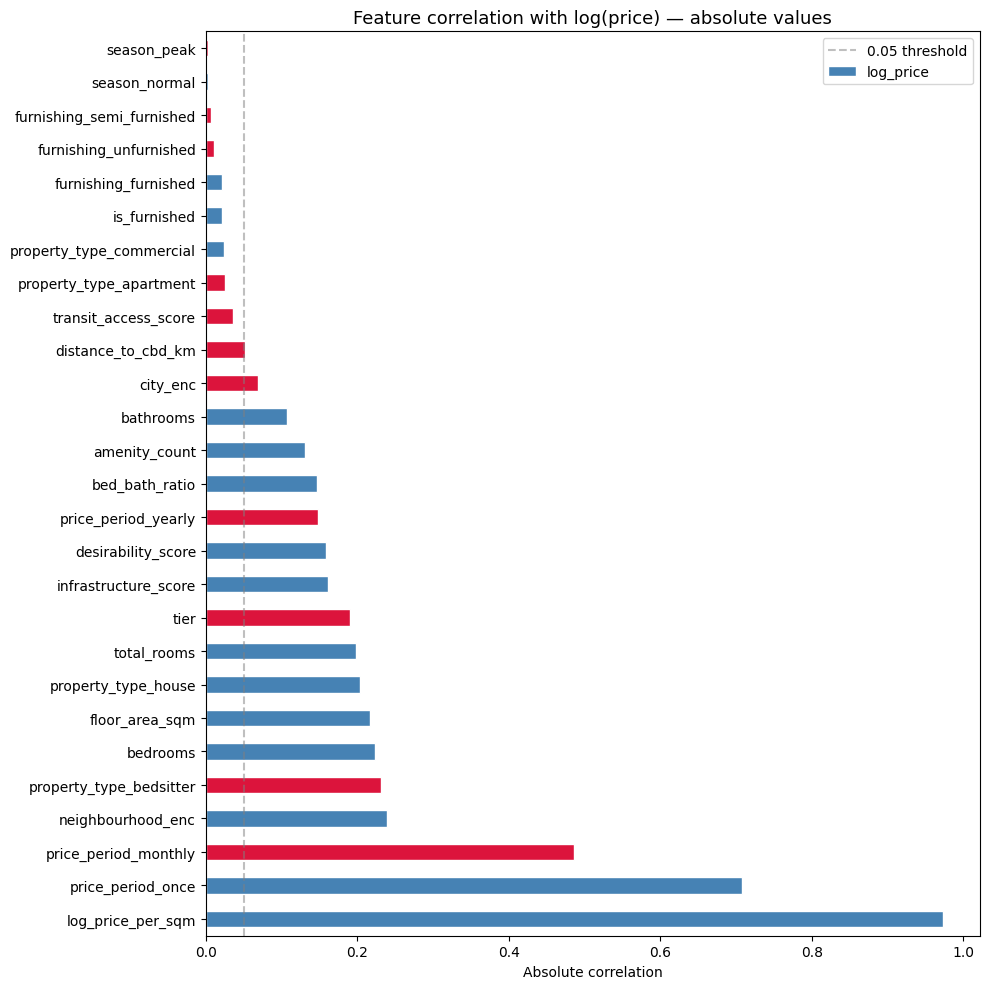

Top 10 features by correlation with log_price:
log_price_per_sqm         0.9734
price_period_once         0.7078
price_period_monthly      0.4856
neighbourhood_enc         0.2395
property_type_bedsitter   0.2309
bedrooms                  0.2230
floor_area_sqm            0.2168
property_type_house       0.2035
total_rooms               0.1983
tier                      0.1902
Name: log_price, dtype: float64

Bottom 5 features (weakest signal):
furnishing_furnished        0.0215
furnishing_unfurnished      0.0110
furnishing_semi_furnished   0.0074
season_normal               0.0036
season_peak                 0.0036
Name: log_price, dtype: float64


In [10]:
train_with_target = X_train_scaled.copy()
train_with_target["log_price"] = y_train.values

correlations = train_with_target.corr()["log_price"].drop("log_price")
correlations = correlations.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ["steelblue" if v > 0 else "crimson"
          for v in train_with_target.corr()["log_price"].drop("log_price")[correlations.index]]
correlations.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title("Feature correlation with log(price) — absolute values", fontsize=13)
ax.set_xlabel("Absolute correlation")
ax.axvline(0.05, color="gray", linestyle="--", alpha=0.5, label="0.05 threshold")
ax.legend()
plt.tight_layout()
plt.savefig("../../ml/reports/02_feature_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 features by correlation with log_price:")
print(correlations.head(10).round(4))
print("\nBottom 5 features (weakest signal):")
print(correlations.tail(5).round(4))

>This chart shows which features have the strongest linear relationship with the target. Features with correlation below 0.05 are weak predictors in isolation — but XGBoost can still use them in combination with others, so we keep them unless they add noise.

# **Save all processed artifacts**

In [11]:
from pathlib import Path
PROCESSED_DIR = Path("../../ml/data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Save train/val/test splits
X_train_scaled.to_csv(PROCESSED_DIR / "X_train.csv", index=False)
X_val_scaled.to_csv(PROCESSED_DIR / "X_val.csv", index=False)
X_test_scaled.to_csv(PROCESSED_DIR / "X_test.csv", index=False)
y_train.to_csv(PROCESSED_DIR / "y_train.csv", index=False)
y_val.to_csv(PROCESSED_DIR / "y_val.csv", index=False)
y_test.to_csv(PROCESSED_DIR / "y_test.csv", index=False)

# Save full fraud dataset for notebook 04
fraud_full = pd.concat([clean_df, fraud_df], ignore_index=True)
fraud_full.to_csv(PROCESSED_DIR / "fraud_dataset.csv", index=False)

# Save scaler and encoders
joblib.dump(scaler, PROCESSED_DIR / "scaler.pkl")
joblib.dump(label_encoders, PROCESSED_DIR / "label_encoders.pkl")

# Save feature names and metadata
metadata = {
    "feature_cols": FEATURE_COLS,
    "target_col": TARGET_COL,
    "numeric_cols": NUMERIC_COLS,
    "n_train": len(X_train),
    "n_val": len(X_val),
    "n_test": len(X_test),
    "cities": list(df.city.unique()),
    "property_types": list(df.property_type.unique()),
}
with open(PROCESSED_DIR / "feature_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved artifacts:")
print(f"  X_train.csv    — {X_train_scaled.shape}")
print(f"  X_val.csv      — {X_val_scaled.shape}")
print(f"  X_test.csv     — {X_test_scaled.shape}")
print(f"  y_train.csv    — {y_train.shape}")
print(f"  y_val.csv      — {y_val.shape}")
print(f"  y_test.csv     — {y_test.shape}")
print(f"  fraud_dataset.csv — {fraud_full.shape}")
print(f"  scaler.pkl")
print(f"  label_encoders.pkl")
print(f"  feature_metadata.json")
print(f"\nFeature engineering complete. Ready for model training.")

Saved artifacts:
  X_train.csv    — (29961, 27)
  X_val.csv      — (6400, 27)
  X_test.csv     — (6417, 27)
  y_train.csv    — (29961,)
  y_val.csv      — (6400,)
  y_test.csv     — (6417,)
  fraud_dataset.csv — (50000, 23)
  scaler.pkl
  label_encoders.pkl
  feature_metadata.json

Feature engineering complete. Ready for model training.


>All processed artifacts are saved to `ml/data/processed/`. The scaler and label encoders are saved as `.pkl` files — these must be loaded at inference time to transform new property data the same way as training data. The metadata JSON records all column names so the ML service knows exactly what features to expect at runtime.

# **Final summary**

In [12]:
print("""
=== FEATURE ENGINEERING SUMMARY ===

Input:   50,000 raw records, 23 columns
Output:  42,500 clean records, 27 engineered features

Transformations applied:
  1. Removed land properties from valuation set (different product)
  2. Log-transformed price — removes right skew
  3. Z-score normalised within city+period — cross-currency comparable
  4. Engineered: price_per_sqm, bed_bath_ratio, desirability_score,
                 size_category, cbd_proximity, season, is_furnished, total_rooms
  5. One-hot encoded: property_type, furnishing, price_period, season
  6. Label encoded: city, neighbourhood, size_category, cbd_proximity
  7. Standard scaled: all numeric columns (fit on train only)
  8. Stratified 70/15/15 split by city

Target variable: log_price (exponentiate predictions for actual values)

Splits:
""")
print(f"  Train:      {len(X_train):,} records")
print(f"  Validation: {len(X_val):,} records")
print(f"  Test:       {len(X_test):,} records")
print(f"\n  Total features: {len(FEATURE_COLS)}")
print(f"  Saved to: ml/data/processed/")
print("\nNext: notebook 03 — train valuation model")


=== FEATURE ENGINEERING SUMMARY ===

Input:   50,000 raw records, 23 columns
Output:  42,500 clean records, 27 engineered features

Transformations applied:
  1. Removed land properties from valuation set (different product)
  2. Log-transformed price — removes right skew
  3. Z-score normalised within city+period — cross-currency comparable
  4. Engineered: price_per_sqm, bed_bath_ratio, desirability_score,
                 size_category, cbd_proximity, season, is_furnished, total_rooms
  5. One-hot encoded: property_type, furnishing, price_period, season
  6. Label encoded: city, neighbourhood, size_category, cbd_proximity
  7. Standard scaled: all numeric columns (fit on train only)
  8. Stratified 70/15/15 split by city

Target variable: log_price (exponentiate predictions for actual values)

Splits:

  Train:      29,961 records
  Validation: 6,400 records
  Test:       6,417 records

  Total features: 27
  Saved to: ml/data/processed/

Next: notebook 03 — train valuation model


**Feature correlations — key insights:**

`log_price_per_sqm` at **0.97** is by far the strongest predictor — price per square metre is essentially the same information as price, just normalised. This is expected and actually good — it means the model has a near-perfect anchor feature to build around.

`price_period_once` at **0.71** and `price_period_monthly` at **0.49** — sale prices are always much higher than rental prices, so price period is the second strongest signal. The model needs to know if it's valuing a rental or a sale.

`neighbourhood_enc` at **0.24** — neighbourhood identity is a strong predictor even as a label-encoded integer, confirming that location drives price significantly.

`bedrooms`, `floor_area_sqm`, `total_rooms` all between **0.20–0.23** — size features are consistent and meaningful.

`tier` at **0.19** — neighbourhood quality tier is a solid signal.

`season_peak/normal` at **0.004** — season has almost zero linear correlation with price, confirming our suspicion. We'll keep it in the model but XGBoost will likely assign it near-zero importance.

**Splits look perfect** — all 6 cities proportionally represented in both train and test. No city is over or under-represented.

Everything saved correctly to `ml/data/processed/`. 

Ready for **notebook 03 — valuation model training**?